# Analysis

## Filling up missing data

In [ ]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the CSV file
file_path = '/content/drive/MyDrive/UMACT 2026/UMACT_HACKATHON_2026_FINALVERSION.csv'

# Read the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully:")
    print(df.info())
    print(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the file path and folder name are correct.")
except Exception as e:
    print(f"An error occurred while reading the CSV: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   claim_id              20000 non-null  object 
 1   policyholder_id       20000 non-null  object 
 2   patient_age           20000 non-null  int64  
 3   patient_gender        20000 non-null  object 
 4   smoker_status         20000 non-null  object 
 5   bmi                   20000 non-null  float64
 6   chronic_conditions    20000 non-null  int64  
 7   has_previous_claims   20000 non-null  int64  
 8   plan_type             20000 non-null  object 
 9   room_and_board_limit  20000 non-null  int64  
 10  patient_state         20000 non-null  object 
 11  region                20000 non-null  object 
 12  hospital_name 

In [ ]:
import numpy as np

# Calculate the expected investigation cost
df['calculated_investigation_cost'] = df['total_claim_amount'] - (df['doctor_fees'] + df['hospital_charges'] + df['medication_cost'])

# Define a tolerance for floating-point comparisons
tolerance = 1e-6 # A common small tolerance, you can adjust this if needed

# Check where investigation_cost is not null and compare with the calculated value
# We use np.isclose to handle floating-point comparisons with a tolerance
mismatched_costs = df[df['investigation_cost'].notna() &
                      ~np.isclose(df['investigation_cost'], df['calculated_investigation_cost'], atol=tolerance)]

# Report the findings
if mismatched_costs.empty:
    print("All non-null 'investigation_cost' values match the calculation 'Total Claim - (Doctor Fees + Hospital Charges + Medication Cost)' within a small tolerance.")
    # Optionally, you can drop the temporary calculated column if no longer needed
    df.drop(columns=['calculated_investigation_cost'], inplace=True)
else:
    print(f"Found {len(mismatched_costs)} discrepancies where 'investigation_cost' does not match the calculation within the set tolerance:")
    print(mismatched_costs[['claim_id', 'investigation_cost', 'calculated_investigation_cost', 'doctor_fees', 'hospital_charges', 'medication_cost', 'total_claim_amount']].head())

# Fill null values in 'investigation_cost' using the formula
df['investigation_cost'] = df.apply(lambda row:
    row['total_claim_amount'] - (row['doctor_fees'] + row['hospital_charges'] + row['medication_cost'])
    if pd.isna(row['investigation_cost']) else row['investigation_cost'], axis=1
)

print("Null values in 'investigation_cost' have been filled using the formula.")
print(f"Number of remaining nulls in 'investigation_cost': {df['investigation_cost'].isnull().sum()}")

All non-null 'investigation_cost' values match the calculation 'Total Claim - (Doctor Fees + Hospital Charges + Medication Cost)' within a small tolerance.
Null values in 'investigation_cost' have been filled using the formula.
Number of remaining nulls in 'investigation_cost': 0


In [ ]:
# Convert date columns to datetime objects if not already done
df['admission_date'] = pd.to_datetime(df['admission_date'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

# --- Logic Checks on Dates ---
print("\n--- Logic Checks on Dates ---")

# Calculate length_of_stay from dates for non-null discharge/admission dates
df['calculated_los_from_dates'] = (df['discharge_date'] - df['admission_date']).dt.days

# Identify rows where both existing 'length_of_stay' and 'calculated_los_from_dates' are non-null
both_notna = df['length_of_stay'].notna() & df['calculated_los_from_dates'].notna()

# Create a temporary Series for 'length_of_stay' that is converted to integer only for non-null values
existing_los_int = df.loc[both_notna, 'length_of_stay'].astype(int)
calculated_los_int = df.loc[both_notna, 'calculated_los_from_dates']

# Compare these two Series to find discrepancies
discrepancies = df[both_notna][existing_los_int != calculated_los_int]

if not discrepancies.empty:
    print(f"Found {len(discrepancies)} discrepancies between existing 'length_of_stay' and 'length_of_stay' calculated from dates:")
    display(discrepancies[['claim_id', 'admission_date', 'discharge_date', 'length_of_stay', 'calculated_los_from_dates']].head())
else:
    print("No discrepancies found between existing 'length_of_stay' and 'length_of_stay' calculated from dates for non-null values.")

# Drop the temporary column
df.drop(columns=['calculated_los_from_dates'], inplace=True, errors='ignore')

# --- Handle missing length_of_stay ---
# Identify rows where length_of_stay is null
missing_los_mask = df['length_of_stay'].isnull()

# Calculate length_of_stay for missing values
# Ensure room_and_board_limit is not zero to avoid division by zero
df.loc[missing_los_mask, 'length_of_stay'] = (
    df.loc[missing_los_mask, 'rb_entitlement_total'] /
    df.loc[missing_los_mask, 'room_and_board_limit']
)

df['length_of_stay'] = df['length_of_stay'].round().astype(int)

print(f"Number of remaining nulls in 'length_of_stay' after calculation: {df['length_of_stay'].isnull().sum()}")

# --- Handle missing discharge_date ---
# Identify rows where discharge_date is null
missing_discharge_date_mask = df['discharge_date'].isnull()

# Fill missing discharge_date by adding length_of_stay (in days) to admission_date
df.loc[missing_discharge_date_mask, 'discharge_date'] = (
    df.loc[missing_discharge_date_mask, 'admission_date'] +
    pd.to_timedelta(df.loc[missing_discharge_date_mask, 'length_of_stay'], unit='D')
)

print(f"Number of remaining nulls in 'discharge_date' after calculation: {df['discharge_date'].isnull().sum()}")

print("Missing values for 'length_of_stay' and 'discharge_date' have been filled.")


--- Logic Checks on Dates ---
No discrepancies found between existing 'length_of_stay' and 'length_of_stay' calculated from dates for non-null values.
Number of remaining nulls in 'length_of_stay' after calculation: 0
Number of remaining nulls in 'discharge_date' after calculation: 0
Missing values for 'length_of_stay' and 'discharge_date' have been filled.


In [ ]:
missing_copay_mask = df['patient_co_payment'].isnull()

df.loc[missing_copay_mask, 'patient_co_payment'] = (
    df.loc[missing_copay_mask, 'total_claim_amount'] -
    df.loc[missing_copay_mask, 'insurance_paid']
)

print(f"Number of remaining nulls in 'patient_co_payment': {df['patient_co_payment'].isnull().sum()}")

Number of remaining nulls in 'patient_co_payment': 0


In [ ]:
import numpy as np

# Create a mapping from sub_category to major_category using non-null entries
major_category_mapping = df[df['major_category'].notna()].groupby('sub_category')['major_category'].first().to_dict()

# Fill null values in 'major_category' based on the mapping
missing_major_category_mask = df['major_category'].isnull()
df.loc[missing_major_category_mask, 'major_category'] = \
    df.loc[missing_major_category_mask, 'sub_category'].map(major_category_mapping)

print(f"Number of remaining nulls in 'major_category': {df['major_category'].isnull().sum()}")

# Check if any nulls remain, which could happen if a sub_category had no corresponding major_category in the non-null data.
if df['major_category'].isnull().sum() > 0:
    print("Warning: Some 'major_category' values could not be filled because their 'sub_category' did not have a corresponding 'major_category' in the non-null data.")


Number of remaining nulls in 'major_category': 0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   claim_id              20000 non-null  object        
 1   policyholder_id       20000 non-null  object        
 2   patient_age           20000 non-null  int64         
 3   patient_gender        20000 non-null  object        
 4   smoker_status         20000 non-null  object        
 5   bmi                   20000 non-null  float64       
 6   chronic_conditions    20000 non-null  int64         
 7   has_previous_claims   20000 non-null  int64         
 8   plan_type             20000 non-null  object        
 9   room_and_board_limit  20000 non-null  int64         
 10  patient_state         20000 non-null  object        
 11  region                20000 non-null  object        
 12  hospital_name         20000 non-null  object        
 13  hospital_type   

In [ ]:
output_file_path = '/content/drive/MyDrive/UMACT 2026/UMACT_HACKATHON_2026_CLEANED.csv'
df.to_csv(output_file_path, index=False)
print(f"DataFrame successfully exported to '{output_file_path}'")

DataFrame successfully exported to '/content/drive/MyDrive/UMACT 2026/UMACT_HACKATHON_2026_CLEANED.csv'


## EDA

In [ ]:
import pandas as pd

# Define the path to the cleaned CSV file
cleaned_file_path = '/content/drive/MyDrive/UMACT 2026/UMACT_HACKATHON_2026_CLEANED.csv'

# Read the CSV file into a pandas DataFrame
try:
    df_cleaned = pd.read_csv(cleaned_file_path)
    print("Cleaned dataset loaded successfully:")
    print(df_cleaned.info())
    print(df_cleaned.head())
except FileNotFoundError:
    print(f"Error: The cleaned file '{cleaned_file_path}' was not found. Please ensure the file path is correct.")
except Exception as e:
    print(f"An error occurred while reading the CSV: {e}")

Cleaned dataset loaded successfully:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   claim_id              20000 non-null  object 
 1   policyholder_id       20000 non-null  object 
 2   patient_age           20000 non-null  int64  
 3   patient_gender        20000 non-null  object 
 4   smoker_status         20000 non-null  object 
 5   bmi                   20000 non-null  float64
 6   chronic_conditions    20000 non-null  int64  
 7   has_previous_claims   20000 non-null  int64  
 8   plan_type             20000 non-null  object 
 9   room_and_board_limit  20000 non-null  int64  
 10  patient_state         20000 non-null  object 
 11  region                20000 non-null  object 
 12  hospital_name         20000 non-null  object 
 13  hospital_type         20000 non-null  object 
 14  admission_type        20000 non-n

In [ ]:
import pandas as pd

# Iterate through each column to display unique values
for col in df_cleaned.columns:
    unique_vals = df_cleaned[col].unique()
    num_unique = len(unique_vals)

    print(f"Column: {col} ({num_unique} unique values)")
    if num_unique <= 20:
        print(f"Values: {unique_vals}")
    else:
        print(f"Sample values: {unique_vals[:5]}...")
    print("-" * 30)

Column: claim_id (20000 unique values)
Sample values: ['MHC0000001' 'MHC0000002' 'MHC0000003' 'MHC0000004' 'MHC0000005']...
------------------------------
Column: policyholder_id (8635 unique values)
Sample values: ['PH02843' 'PH07593' 'PH00983' 'PH03707' 'PH05756']...
------------------------------
Column: patient_age (85 unique values)
Sample values: [ 4 33  1 17 53]...
------------------------------
Column: patient_gender (2 unique values)
Values: ['F' 'M']
------------------------------
Column: smoker_status (2 unique values)
Values: ['Non-Smoker' 'Smoker']
------------------------------
Column: bmi (386 unique values)
Sample values: [27.1 15.2 27.6 30.2 30.4]...
------------------------------
Column: chronic_conditions (5 unique values)
Values: [0 1 2 4 3]
------------------------------
Column: has_previous_claims (2 unique values)
Values: [0 1]
------------------------------
Column: plan_type (4 unique values)
Values: ['Gold' 'Basic' 'Silver' 'Platinum']
-------------------------

### Claim Severity Distribution Fitting



In [ ]:
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
quantiles = df_cleaned['total_claim_amount'].quantile(percentiles)

print("Percentiles for 'total_claim_amount':")
print(quantiles)

Percentiles for 'total_claim_amount':
0.25     21503.8775
0.50     32318.0350
0.75     89327.6700
0.90    150903.2660
0.95    183229.7810
0.99    234389.3530
Name: total_claim_amount, dtype: float64


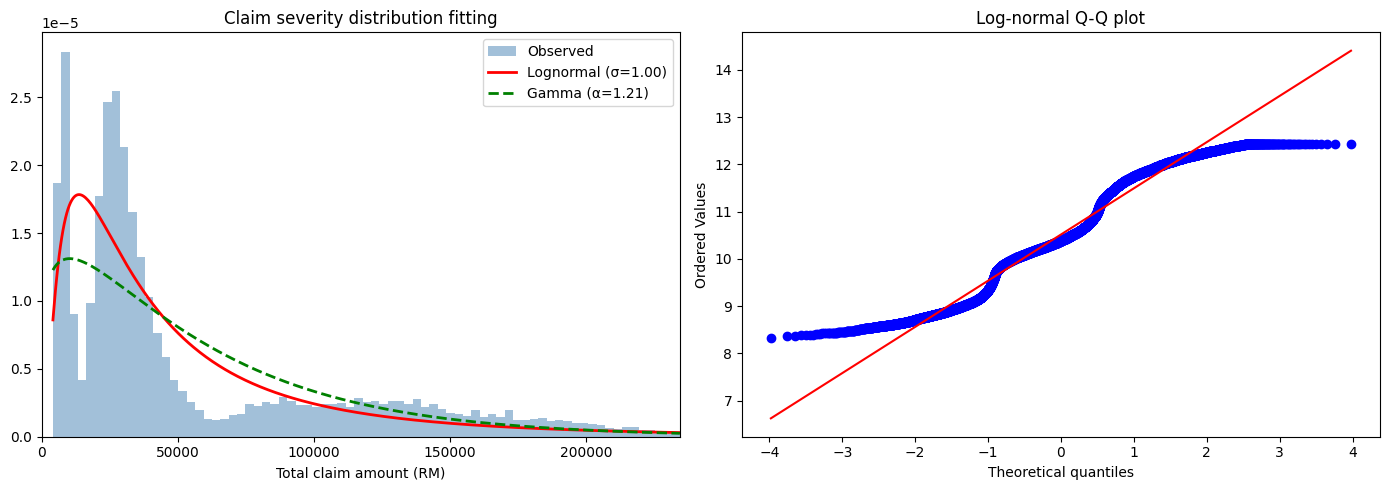

KS test — Lognormal: statistic=0.0715, p=0.0000
KS test — Gamma:     statistic=0.1375,  p=0.0000


In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

claims = df_cleaned['total_claim_amount'].dropna()
claims = claims[claims > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with fitted distributions
axes[0].hist(claims, bins=80, density=True, alpha=0.5, color='steelblue', label='Observed')

# Fit lognormal (most common for health claims)
mu, sigma = stats.lognorm.fit(claims, floc=0)[0:2]  # shape, loc, scale
shape_ln, loc_ln, scale_ln = stats.lognorm.fit(claims, floc=0)
x = np.linspace(claims.min(), claims.quantile(0.99), 500)
axes[0].plot(x, stats.lognorm.pdf(x, shape_ln, loc_ln, scale_ln),
             'r-', lw=2, label=f'Lognormal (σ={shape_ln:.2f})')

# Fit gamma
a, loc_g, scale_g = stats.gamma.fit(claims, floc=0)
axes[0].plot(x, stats.gamma.pdf(x, a, loc_g, scale_g),
             'g--', lw=2, label=f'Gamma (α={a:.2f})')

axes[0].set_xlim(0, claims.quantile(0.99))
axes[0].set_xlabel('Total claim amount (RM)')
axes[0].set_title('Claim severity distribution fitting')
axes[0].legend()

# Q-Q plot for lognormal
stats.probplot(np.log(claims), dist='norm', plot=axes[1])
axes[1].set_title('Log-normal Q-Q plot')
plt.tight_layout()
plt.show()

# Goodness-of-fit: Kolmogorov-Smirnov test
ks_ln = stats.kstest(claims, 'lognorm', args=(shape_ln, loc_ln, scale_ln))
ks_g  = stats.kstest(claims, 'gamma',   args=(a, loc_g, scale_g))
print(f"KS test — Lognormal: statistic={ks_ln.statistic:.4f}, p={ks_ln.pvalue:.4f}")
print(f"KS test — Gamma:     statistic={ks_g.statistic:.4f},  p={ks_g.pvalue:.4f}")

Real-world claim severity data is notoriously messy. The multimodal (multiple peaks) nature of the histogram suggests that the data might actually be a combination of different underlying populations. For instance, small routine claims might follow one distribution, while major catastrophic claims follow another.

Therefore, the approach we are taking are as follow:

> Segment by major_category


    → within each, optionally segment by hospital_type
    → exclude or separately model hits_cap = True claims
    → then fit lognormal/gamma to each clean segment

In [ ]:
import numpy as np
from scipy import stats
import pandas as pd

# Filter for 'clean' segments: exclude claims that hit the cap
df_uncapped = df_cleaned[df_cleaned['hits_cap'] == False].copy()

segments = []
# Segmenting by Major Category and Hospital Type
for (cat, h_type), group in df_uncapped.groupby(['major_category', 'hospital_type']):
    claims_segment = group['total_claim_amount']

    if len(claims_segment) < 30:
        continue

    # Fit Lognormal
    shape_ln, loc_ln, scale_ln = stats.lognorm.fit(claims_segment, floc=0)
    ks_ln = stats.kstest(claims_segment, 'lognorm', args=(shape_ln, loc_ln, scale_ln))

    # Fit Gamma
    a_g, loc_g, scale_g = stats.gamma.fit(claims_segment, floc=0)
    ks_g = stats.kstest(claims_segment, 'gamma', args=(a_g, loc_g, scale_g))

    segments.append({
        'Category': cat,
        'Hospital': h_type,
        'Count': len(claims_segment),
        'Mean': claims_segment.mean(),
        'LN_KS_Stat': ks_ln.statistic,
        'LN_P_Value': ks_ln.pvalue,
        'Gamma_P_Value': ks_g.pvalue
    })

results_df = pd.DataFrame(segments)
print("--- Segmented Distribution Fitting (Uncapped Claims) ---")
print(results_df.sort_values('LN_P_Value', ascending=False).to_string(index=False))

--- Segmented Distribution Fitting (Uncapped Claims) ---
  Category   Hospital  Count        Mean  LN_KS_Stat  LN_P_Value  Gamma_P_Value
Obstetrics Government    357 9015.537283    0.064515    0.098008       0.031281
   Medical Government   3221 8379.615402    0.024418    0.042237       0.000532


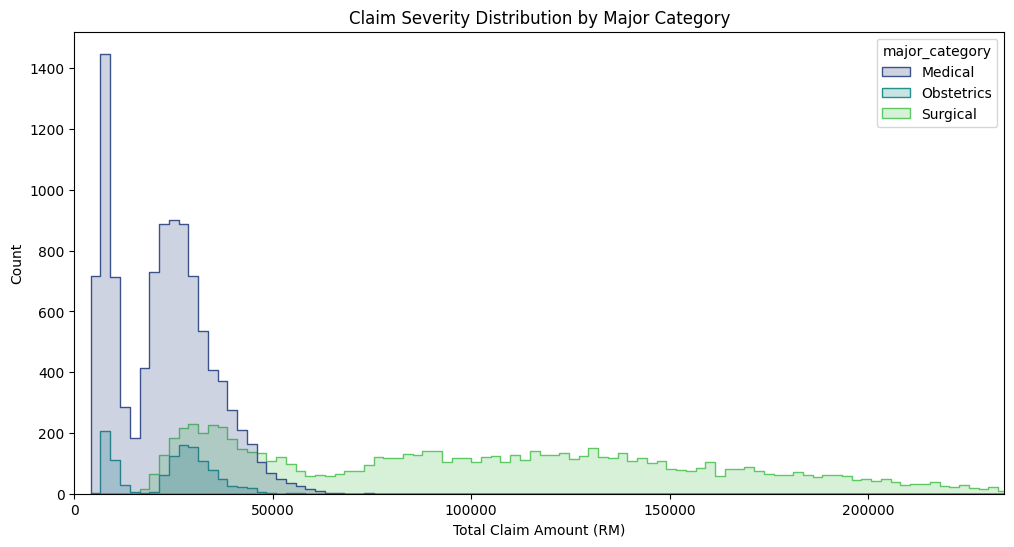

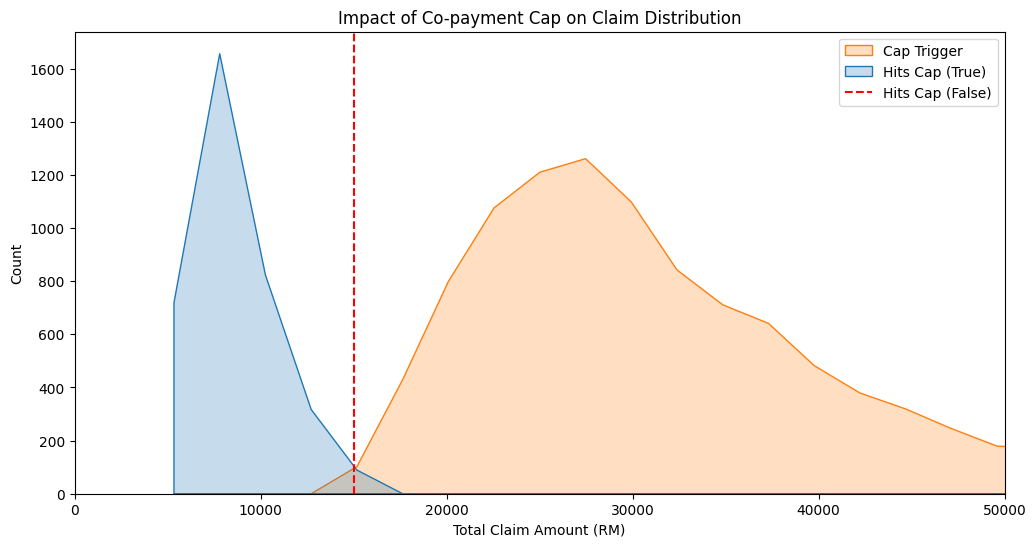

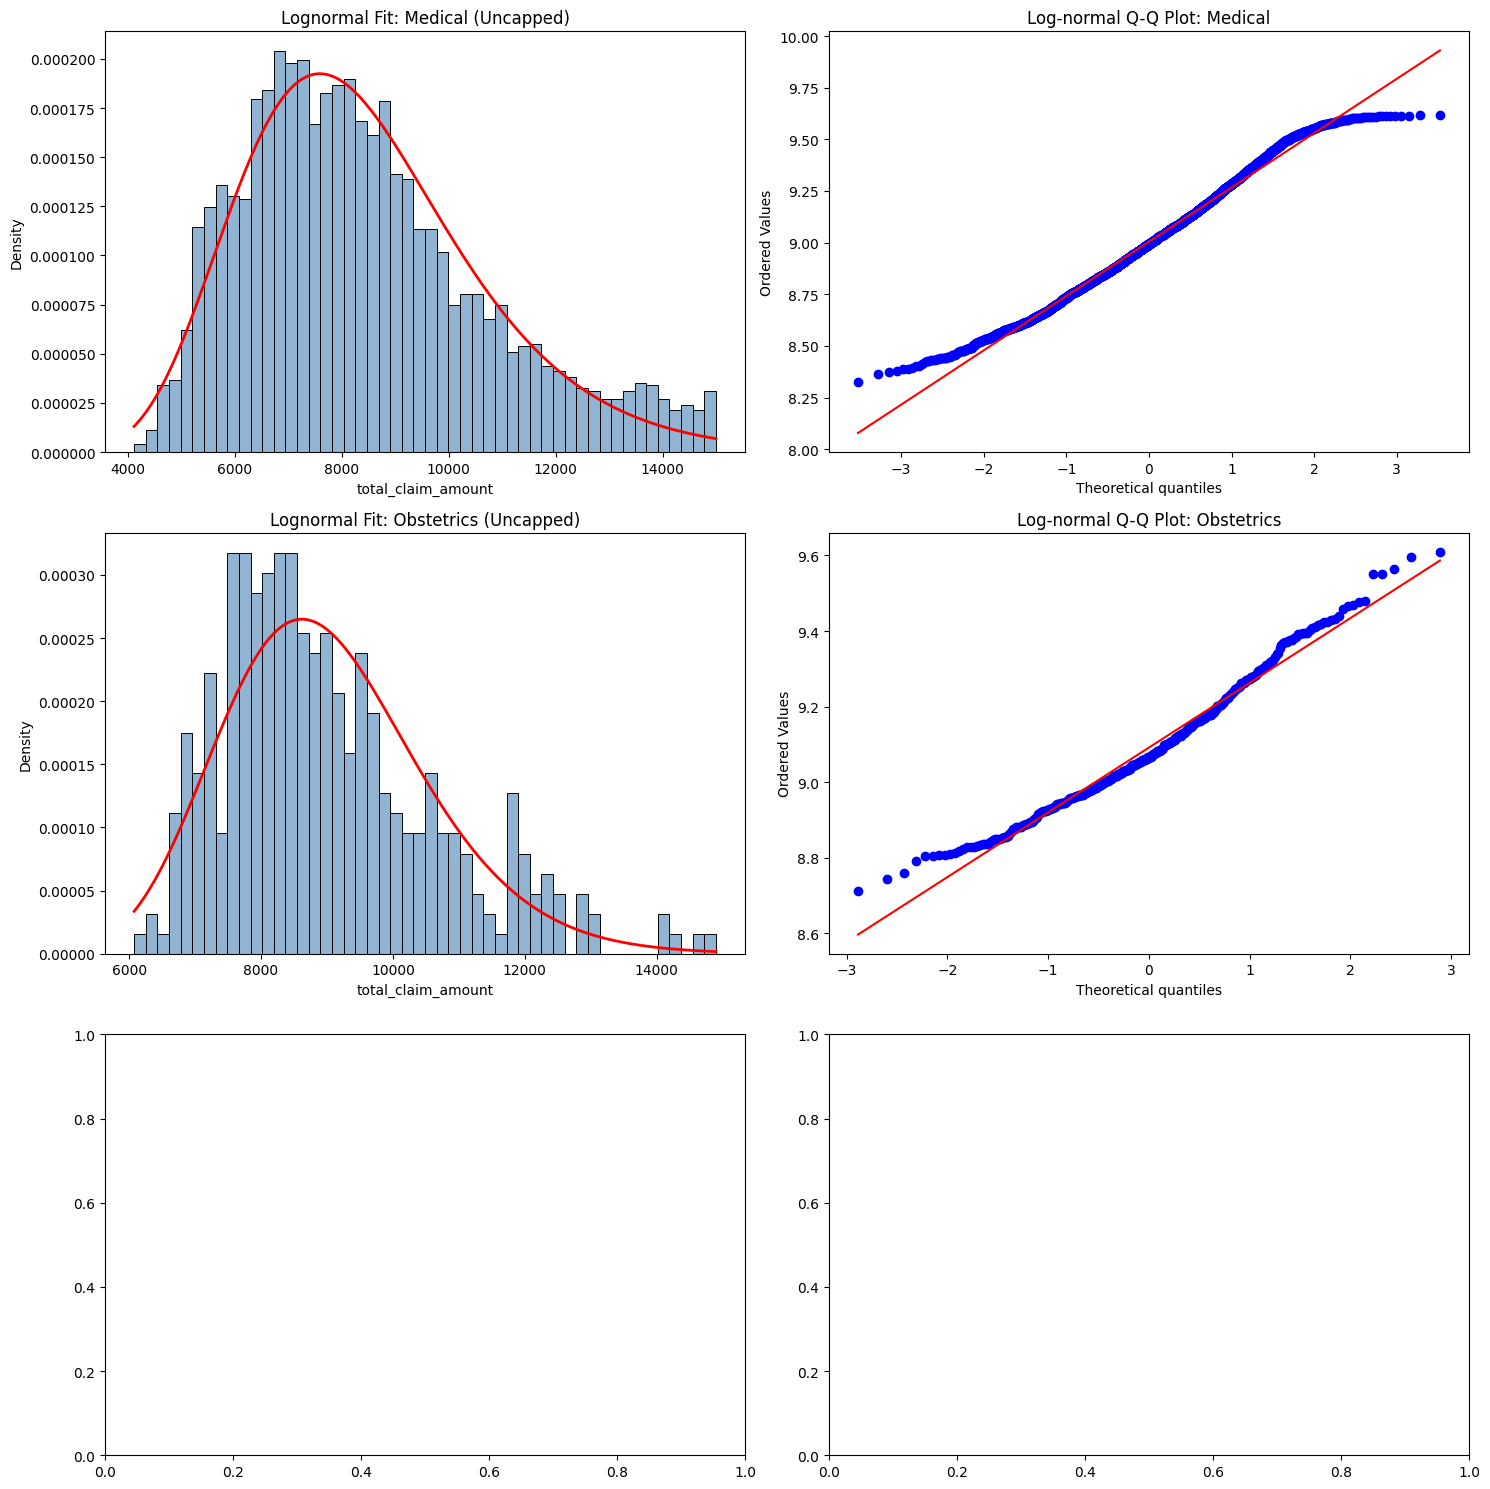

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# 1. Histogram by major_category (overlaid)
plt.figure(figsize=(12, 6))
sns.histplot(data=df_cleaned, x='total_claim_amount', hue='major_category', element='step', palette='viridis', bins=100)
plt.title('Claim Severity Distribution by Major Category')
plt.xlabel('Total Claim Amount (RM)')
plt.xlim(0, df_cleaned['total_claim_amount'].quantile(0.99))
plt.show()

# 7. Histogram — capped vs. uncapped claims overlaid
plt.figure(figsize=(12, 6))
sns.histplot(data=df_cleaned, x='total_claim_amount', hue='hits_cap', element='poly', bins=100)
plt.axvline(15000, color='red', linestyle='--', label='Cap Trigger (RM 15k)')
plt.title('Impact of Co-payment Cap on Claim Distribution')
plt.xlabel('Total Claim Amount (RM)')
plt.xlim(0, 50000) # Zooming in to see the cap effect
plt.legend(['Cap Trigger', 'Hits Cap (True)', 'Hits Cap (False)'])
plt.show()

# 8 & 9. Distribution fitting and Q-Q plot per major_category
categories = df_cleaned['major_category'].unique()
fig, axes = plt.subplots(len(categories), 2, figsize=(15, 5 * len(categories)))

for i, cat in enumerate(categories):
    # Filter for uncapped claims in this category
    subset = df_cleaned[(df_cleaned['major_category'] == cat) & (df_cleaned['hits_cap'] == False)]['total_claim_amount']

    if len(subset) < 10: continue

    # Histogram + Fit
    sns.histplot(subset, bins=50, kde=False, stat='density', ax=axes[i, 0], color='steelblue', alpha=0.6)
    shape, loc, scale = stats.lognorm.fit(subset, floc=0)
    x_range = np.linspace(subset.min(), subset.max(), 200)
    axes[i, 0].plot(x_range, stats.lognorm.pdf(x_range, shape, loc, scale), 'r-', lw=2)
    axes[i, 0].set_title(f'Lognormal Fit: {cat} (Uncapped)')

    # Q-Q Plot
    stats.probplot(np.log(subset), dist='norm', plot=axes[i, 1])
    axes[i, 1].set_title(f'Log-normal Q-Q Plot: {cat}')

plt.tight_layout()
plt.show()

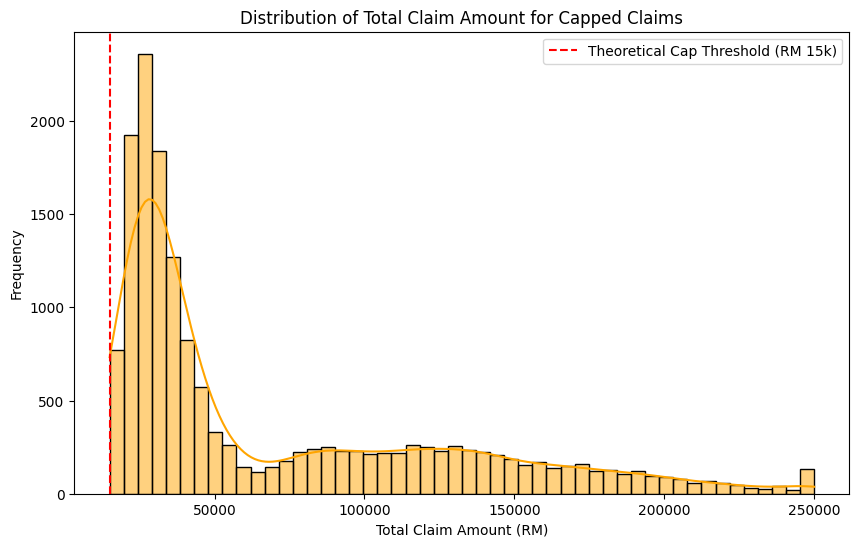

Minimum total claim amount that hits the cap: RM 15,000.65
This confirms that the RM 3,000 co-pay cap is triggered at RM 15,000.65 (20% of 15,000.65 ≈ RM 3,000).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for claims that hit the cap
df_capped = df_cleaned[df_cleaned['hits_cap'] == True]

# Visualize the distribution of total_claim_amount for capped claims
plt.figure(figsize=(10, 6))
sns.histplot(df_capped['total_claim_amount'], bins=50, color='orange', kde=True)
plt.axvline(15000, color='red', linestyle='--', label='Theoretical Cap Threshold (RM 15k)')

plt.title('Distribution of Total Claim Amount for Capped Claims')
plt.xlabel('Total Claim Amount (RM)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Hard-coded logic verification
min_capped_claim = df_capped['total_claim_amount'].min()
print(f"Minimum total claim amount that hits the cap: RM {min_capped_claim:,.2f}")
print(f"This confirms that the RM 3,000 co-pay cap is triggered at RM {min_capped_claim:,.2f} (20% of {min_capped_claim:,.2f} ≈ RM 3,000).")

The analysis reveals that the complex, multi-peaked nature of the aggregate claim severity distribution is fundamentally driven by an RM 3,000 co-payment cap triggering at RM 15,000.65, alongside the blending of distinct clinical categories. By isolating homogenous, uncapped segments—specifically Government Medical and Obstetrics claims—to remove the distortion of the cap and high-variance Surgical claims, we established that **base-level claims statistically fit a Lognormal distribution**. However, despite this predictable uncapped baseline, the aggregate portfolio retains **severe catastrophic tail risk**; this is highlighted by a massive gap between the median claim (RM 32,318) and the 99th percentile (RM 234,389), which is primarily fueled by capped claims and the heavy-tailed Surgical category.

### Claim frequency by risk factor

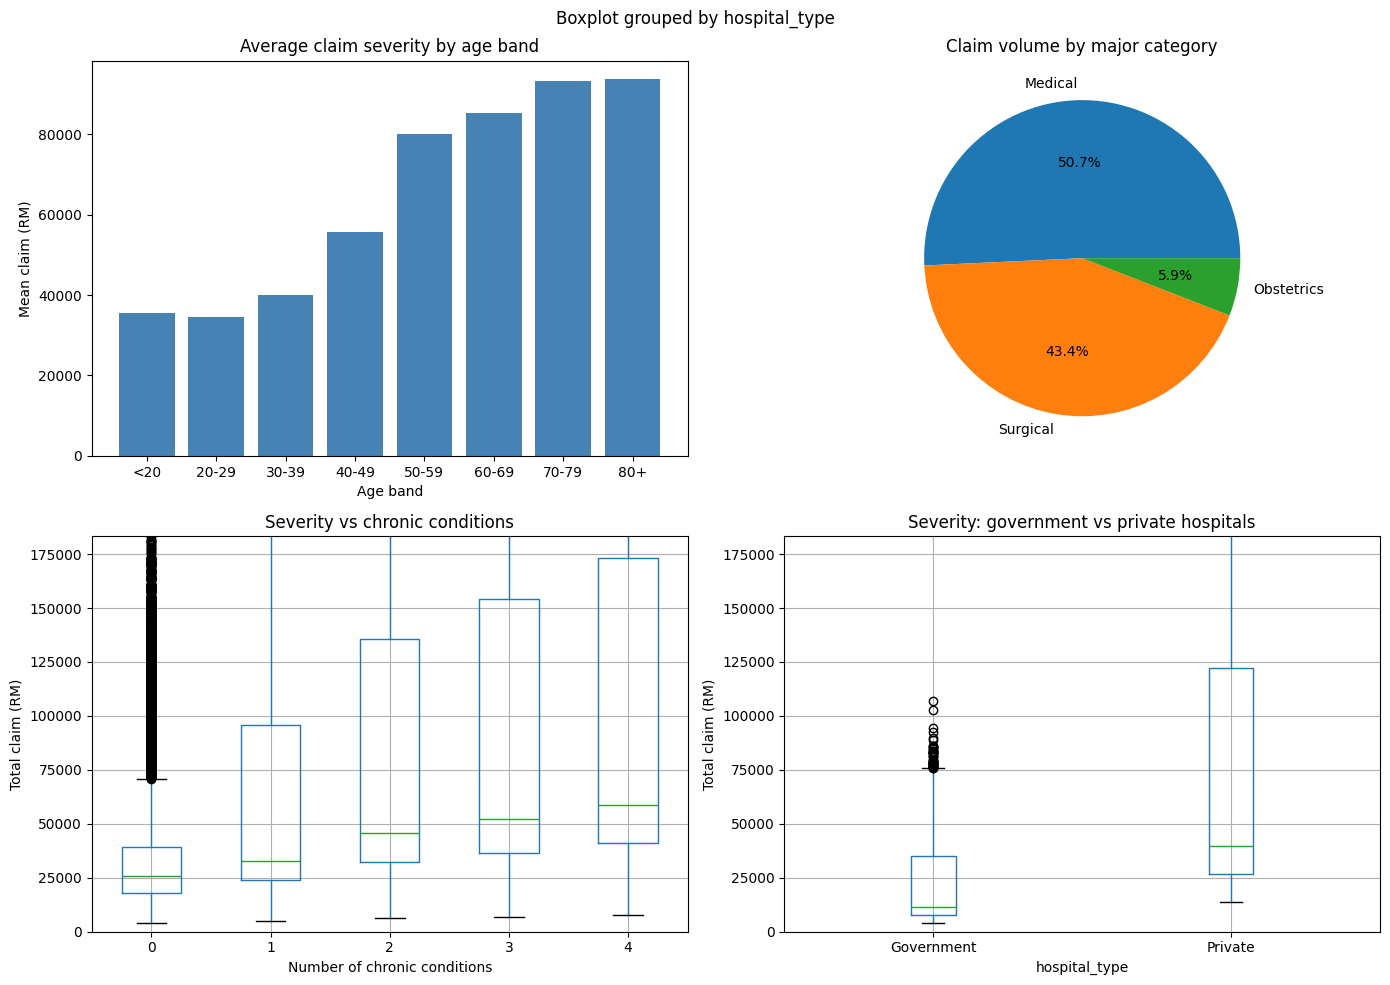

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (i) Age bands — actuarial standard
df_cleaned['age_band'] = pd.cut(df_cleaned['patient_age'],
    bins=[0,20,30,40,50,60,70,80,100],
    labels=['<20','20-29','30-39','40-49','50-59','60-69','70-79','80+'])

avg_claim = df_cleaned.groupby('age_band', observed=True)['total_claim_amount'].mean()
axes[0,0].bar(avg_claim.index, avg_claim.values, color='steelblue')
axes[0,0].set_title('Average claim severity by age band')
axes[0,0].set_xlabel('Age band')
axes[0,0].set_ylabel('Mean claim (RM)')

# (ii) Claim count by major category
cat_counts = df_cleaned['major_category'].value_counts()
axes[0,1].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%')
axes[0,1].set_title('Claim volume by major category')

# (iii) Chronic conditions vs severity
df_cleaned.boxplot(column='total_claim_amount', by='chronic_conditions', ax=axes[1,0])
axes[1,0].set_title('Severity vs chronic conditions')
axes[1,0].set_xlabel('Number of chronic conditions')
axes[1,0].set_ylabel('Total claim (RM)')
plt.sca(axes[1,0]); plt.ylim(0, df_cleaned['total_claim_amount'].quantile(0.95))

# (iv) Hospital type: Government vs Private
df_cleaned.boxplot(column='total_claim_amount', by='hospital_type', ax=axes[1,1])
axes[1,1].set_title('Severity: government vs private hospitals')
axes[1,1].set_ylabel('Total claim (RM)')
plt.sca(axes[1,1]); plt.ylim(0, df_cleaned['total_claim_amount'].quantile(0.95))

plt.tight_layout()
plt.show()

The visual analysis reveals that claim severity is heavily influenced by **demographic, clinical, and facility-based factors**. Specifically, average claim costs accelerate noticeably for patients starting in the 40-49 age band, and these costs compound significantly as the number of underlying chronic conditions increases. From a volume perspective, Medical and Surgical claims dominate the portfolio, accounting for over 94% of total claims combined, while Obstetrics makes up just 5.9%. Furthermore, treatment at **private hospitals yields substantially higher median claim amounts and far greater cost variability compared to government facilities**, highlighting facility choice and patient health complexity as the primary drivers of portfolio severity.

### Medical inflation trend analysis (2023–2025)

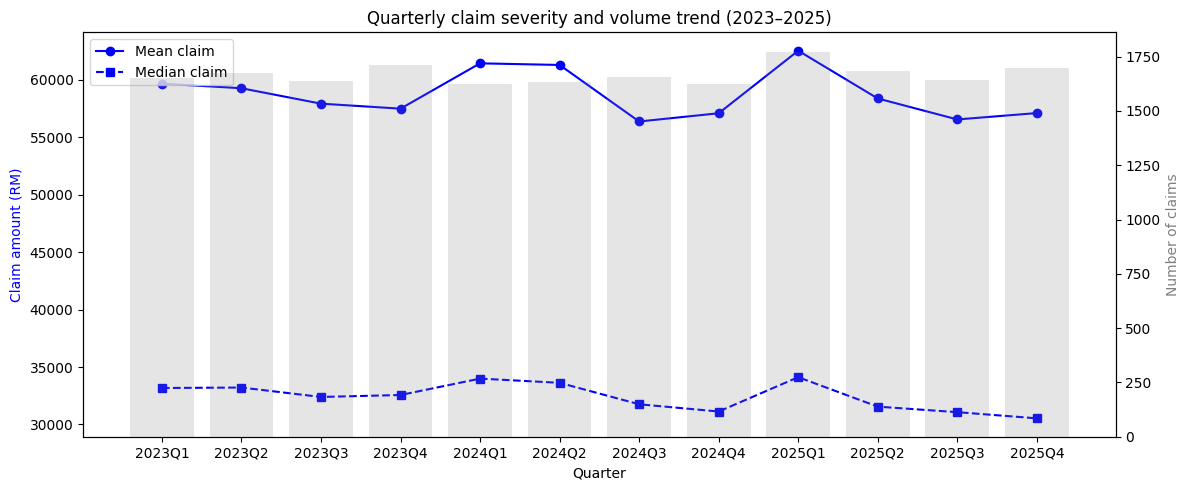

Medical inflation 2023→2024: 0.8%
Medical inflation 2024→2025: -0.6%


In [ ]:
df_cleaned['admission_date'] = pd.to_datetime(df_cleaned['admission_date'])
df_cleaned['discharge_date'] = pd.to_datetime(df_cleaned['discharge_date'])
df_cleaned['year'] = df_cleaned['admission_date'].dt.year
df_cleaned['quarter'] = df_cleaned['admission_date'].dt.to_period('Q')

# Average severity per quarter
quarterly = df_cleaned.groupby('quarter')['total_claim_amount'].agg(['mean','median','count'])
quarterly.index = quarterly.index.astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(quarterly.index, quarterly['mean'],   'b-o', label='Mean claim')
ax1.plot(quarterly.index, quarterly['median'], 'b--s', label='Median claim')
ax2.bar(quarterly.index, quarterly['count'], alpha=0.2, color='gray', label='Claim count')

ax1.set_xlabel('Quarter')
ax1.set_ylabel('Claim amount (RM)', color='blue')
ax2.set_ylabel('Number of claims', color='gray')
ax1.set_title('Quarterly claim severity and volume trend (2023–2025)')
ax1.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Medical inflation rate (CAGR between years)
yearly_mean = df_cleaned.groupby('year')['total_claim_amount'].mean()
for y in [2024, 2025]:
    if y in yearly_mean.index and y-1 in yearly_mean.index:
        inflation = (yearly_mean[y]/yearly_mean[y-1] - 1) * 100
        print(f"Medical inflation {y-1}→{y}: {inflation:.1f}%")

Over the 2023–2025 period, the portfolio exhibited remarkable stability in both claim volume and severity, effectively avoiding any severe upward cost trajectory. Claim volumes remained consistent quarter-over-quarter, while both mean and median claim amounts fluctuated within a narrow, stable band. This flat severity trend directly aligns with the virtually stagnant medical inflation rates observed over the same period (0.8% in 2023–2024 and -0.6% in 2024–2025). Furthermore, the persistent, wide gap between the mean claim (hovering around RM 60,000) and the median claim (near RM 33,000) throughout the three years reinforces that the **portfolio's cost dynamics are driven by consistent, high-severity outliers** rather than systemic, year-over-year cost creep.

### Co-payment impact analysis

Claims hitting the RM3,000 cap: 82.0%
Claims above RM15,000 (cap trigger): 82.0%


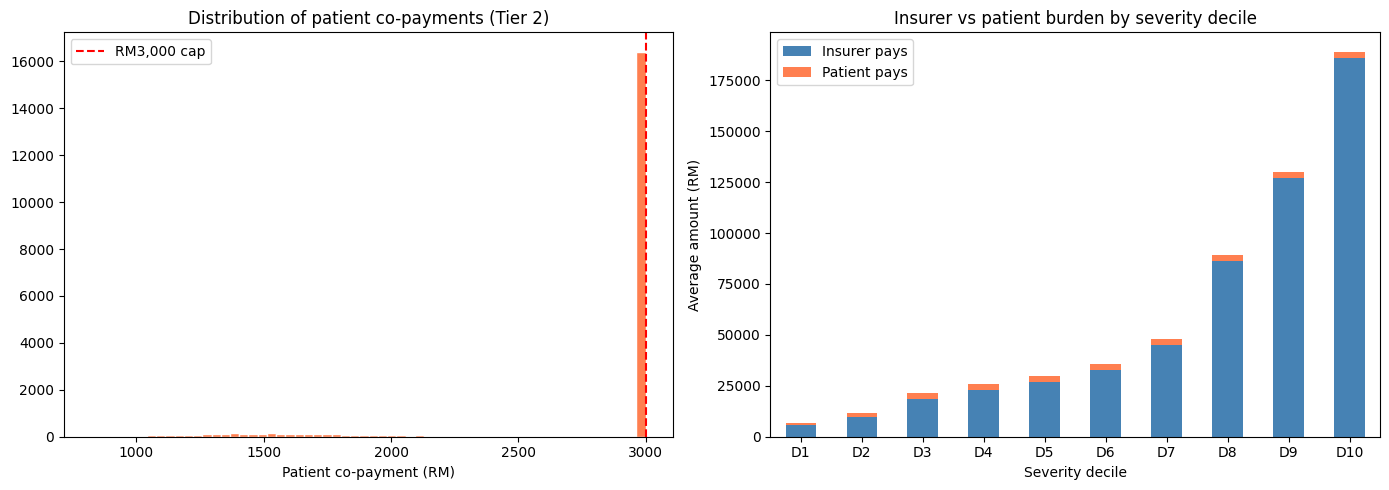

In [ ]:
# Recompute co-payment from scratch to verify dataset consistency
df_cleaned['copay_computed'] = np.minimum(df_cleaned['total_claim_amount'] * 0.20, 3000)
df_cleaned['insurance_paid_computed'] = df_cleaned['total_claim_amount'] - df_cleaned['copay_computed']

# What % of claims hit the RM3,000 cap?
cap_rate = (df_cleaned['copay_computed'] >= 3000).mean() * 100
print(f"Claims hitting the RM3,000 cap: {cap_rate:.1f}%")

# The RM3,000 cap is triggered when total_claim > RM15,000
# (since 20% × 15,000 = 3,000)
print(f"Claims above RM15,000 (cap trigger): "
      f"{(df_cleaned['total_claim_amount'] > 15000).mean()*100:.1f}%")

# Distribution of policyholder out-of-pocket burden
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_cleaned['copay_computed'], bins=60, color='coral', edgecolor='white')
axes[0].axvline(3000, color='red', linestyle='--', label='RM3,000 cap')
axes[0].set_xlabel('Patient co-payment (RM)')
axes[0].set_title('Distribution of patient co-payments (Tier 2)')
axes[0].legend()

# Insurer's burden vs policyholder burden by severity decile
df_cleaned['severity_decile'] = pd.qcut(df_cleaned['total_claim_amount'], 10,
                                       labels=[f'D{i}' for i in range(1,11)])
burden = df_cleaned.groupby('severity_decile', observed=True).agg(
    insurer=('insurance_paid_computed','mean'),
    patient=('copay_computed','mean')
)
burden.plot(kind='bar', stacked=True, ax=axes[1], color=['steelblue','coral'])
axes[1].set_title('Insurer vs patient burden by severity decile')
axes[1].set_xlabel('Severity decile')
axes[1].set_ylabel('Average amount (RM)')
axes[1].legend(['Insurer pays','Patient pays'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The analysis demonstrates that the current Tier 2 co-payment structure is highly ineffective at proportionately distributing the financial burden of severe claims. With 82% of claims exceeding the RM 15,000 threshold, the RM 3,000 patient out-of-pocket cap is triggered almost universally, resulting in a massive concentration of co-payments exactly at the limit. Consequently, as total claim costs escalate across the upper severity deciles, the patient's contribution shrinks to a negligible fraction. This dynamic forces the insurer to absorb nearly the entirety of the cost for the most expensive cases, indicating that the current cap functions more as a flat fee than a true cost-sharing mechanism, offering the insurer minimal protection against catastrophic tail risk.

### Loss ratio analysis by segment

                         avg_claim  avg_insurer_pay  claim_count  pct_hit_cap
plan_type region                                                             
Basic     Central         71457.94         68630.34         1446         0.84
          East Coast      53929.10         51173.78         1476         0.82
          East Malaysia   48615.79         45889.40         1498         0.81
          Northern        59362.85         56590.69         2039         0.82
          Southern        61980.79         59202.38         1493         0.82
Gold      Central         72252.90         69418.26          676         0.85
          East Coast      52174.21         49448.28          698         0.81
          East Malaysia   52086.39         49337.20          763         0.81
          Northern        55385.50         52649.58         1111         0.80
          Southern        63171.55         60390.85          693         0.83
Platinum  Central         73443.28         70657.36          290

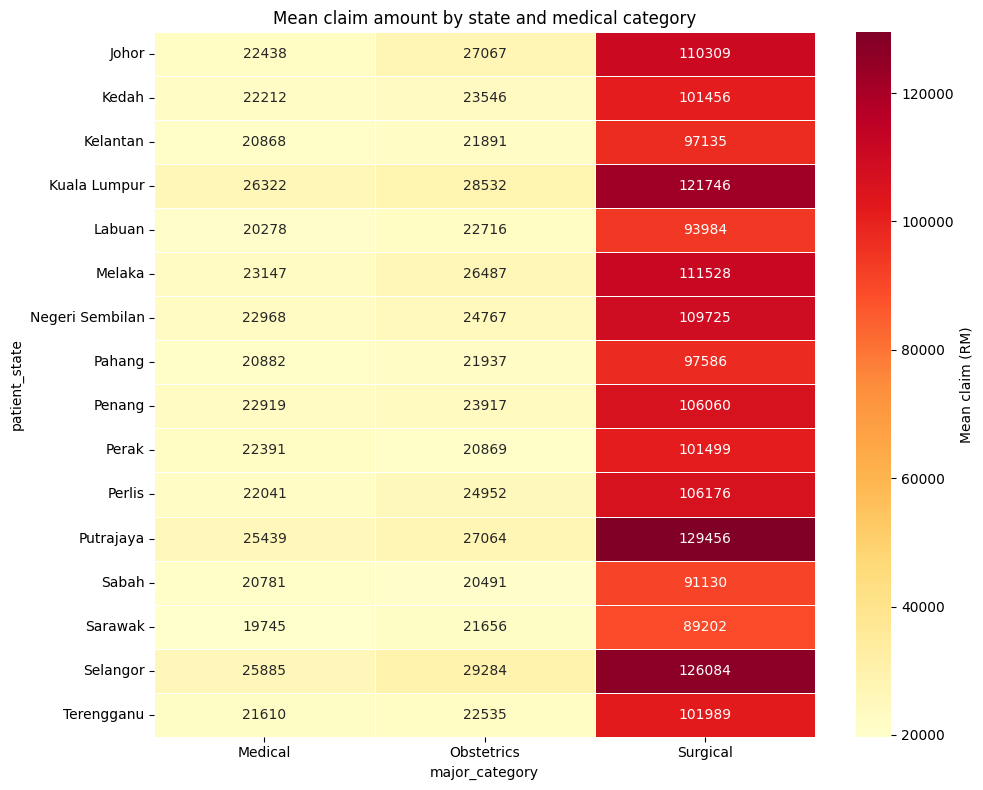

In [ ]:
# Pure premium = Expected claims cost per policyholder

# Proxy: average insurance_paid per claim, by segment
loss_analysis = df_cleaned.groupby(['plan_type','region']).agg(
    avg_claim       = ('total_claim_amount', 'mean'),
    avg_insurer_pay = ('insurance_paid_computed', 'mean'),
    claim_count     = ('claim_id', 'count'),
    pct_hit_cap     = ('hits_cap', 'mean')
).round(2)

print(loss_analysis.to_string())

# Heat map of average claim by state and major category
pivot = df_cleaned.pivot_table(values='total_claim_amount',
                              index='patient_state',
                              columns='major_category',
                              aggfunc='mean')
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Mean claim (RM)'})
plt.title('Mean claim amount by state and medical category')
plt.tight_layout()
plt.show()

The geographic location and clinical category strongly dictate claim severity, with Surgical procedures in the Central region—specifically Putrajaya, Selangor, and Kuala Lumpur—driving the highest overall costs. The regional data reinforces this geographic disparity, showing the Central region consistently recording the highest average claims (roughly RM 69,000 to RM 73,000) across all plan tiers, while East Malaysia reports the lowest. However, despite these significant regional and product-tier cost variations, the percentage of claims triggering the co-payment cap remains uniformly high, fluctuating narrowly between 79% and 85% across all segments. This uniform cap breach indicates that the current **co-payment threshold is set too low to effectively capture regional pricing nuances or differentiate cost-sharing mechanisms** across distinct insurance plan tiers.

### Clustering analysis

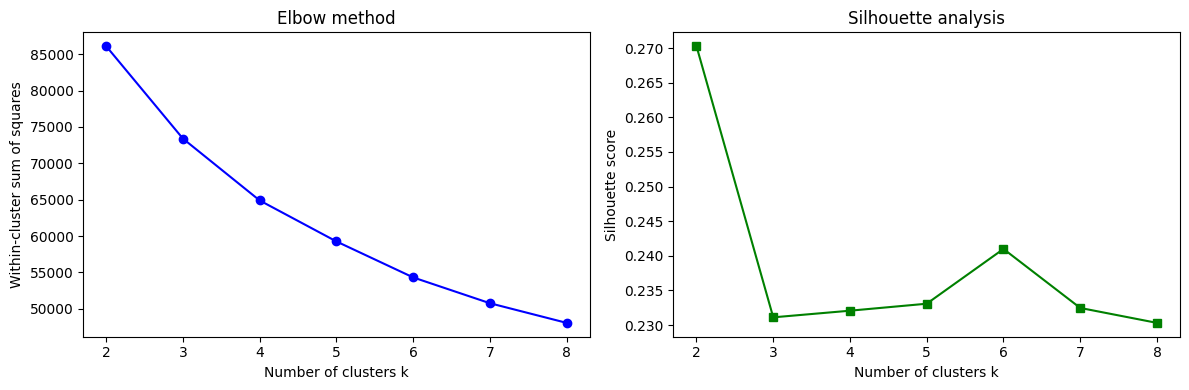

              patient_age    bmi  chronic_conditions  length_of_stay  \
risk_cluster                                                           
0.0                 27.51  27.08                0.41            4.12   
1.0                 62.77  27.11                1.89            7.01   

              total_claim_amount  has_previous_claims  
risk_cluster                                           
0.0                     31621.18                 0.57  
1.0                     98606.08                 0.56  


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ['patient_age','bmi','chronic_conditions','length_of_stay',
            'total_claim_amount','has_previous_claims']
X = df_cleaned[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method to choose k
inertia = []
sil_scores = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Within-cluster sum of squares')
axes[0].set_title('Elbow method')
axes[1].plot(K_range, sil_scores, 'gs-')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette analysis')
plt.tight_layout()
plt.show()

# Fit chosen k and profile each cluster
k_opt = K_range[np.argmax(sil_scores)]
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_cleaned.loc[X.index, 'risk_cluster'] = km_final.fit_predict(X_scaled)

cluster_profile = df_cleaned.groupby('risk_cluster')[features].mean().round(2)
print(cluster_profile)

Based on the clustering evaluation metrics, the silhouette analysis identifies k=2 as the optimal number of segments for the patient population, effectively splitting the data into distinct low-risk and high-risk profiles. The low-risk cluster represents younger patients (average age ~27.5) with minimal chronic conditions, shorter hospital stays (roughly 4 days), and baseline average claim costs of approximately RM 31,621. In stark contrast, the high-risk cluster is characterized by older individuals (average age ~62.8) burdened with multiple chronic conditions, requiring prolonged hospital stays (7 days), and incurring severe average claim costs approaching RM 98,606. Notably, average BMI and the likelihood of having previous claims were practically identical across both groups, highlighting that **advanced age and chronic condition load are the primary drivers of catastrophic claim severity** rather than general weight or prior claim history.

# Modelling

In [ ]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/UMACT 2026/UMACT_HACKATHON_2026_CLEANED.csv'
df = pd.read_csv(file_path)
print("Cleaned dataset loaded successfully.")
print(df.info())
print(df.head())

Mounted at /content/drive
Cleaned dataset loaded successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   claim_id              20000 non-null  object 
 1   policyholder_id       20000 non-null  object 
 2   patient_age           20000 non-null  int64  
 3   patient_gender        20000 non-null  object 
 4   smoker_status         20000 non-null  object 
 5   bmi                   20000 non-null  float64
 6   chronic_conditions    20000 non-null  int64  
 7   has_previous_claims   20000 non-null  int64  
 8   plan_type             20000 non-null  object 
 9   room_and_board_limit  20000 non-null  int64  
 10  patient_state         20000 non-null  object 
 11  region                20000 non-null  object 
 12  hospital_name         20000 non-null  object 
 13  hospital_type         20000 non-null  object 
 14  admissi

## Feature Engineering

To build an actuarially sound pricing model and align with the policy goals of the **Base MHIT Plan**, we must transform our cleaned dataset into predictive, policy-relevant variables. We engineered three core features to support our analytical framework:

**1. Diagnosis-Related Groups (DRG) Alignment**
* **The Problem:** Modeling 15 individual `procedure_diagnosis` strings fragments our data and reduces statistical credibility.
* **The Solution:** In direct alignment with the White Paper's mandate to transition to DRG-based payments, we mapped the 15 specific procedures into 5 broad, resource-comparable clinical categories (e.g., grouping "CABG" and "Angioplasty" into "Cardiovascular"). This reduces dimensionality and allows our model to learn macro-level cost drivers.

**2. Patient Complexity Risk Score (Actuarial Multiplier)**
* **The Problem:** Age, BMI, smoking status, and chronic conditions all independently drive costs, but feeding them raw into a severity model can sometimes dilute their combined impact.
* **The Solution:** We engineered a composite `patient_risk_score`. Starting with a baseline of $1.0$, we applied actuarial penalties for high BMI ($+0.15$), smoking ($+0.25$), advanced age (up to $+0.50$), and chronic conditions ($+0.20$ per condition).

**3. Hospital Efficiency Metric (Cost Per Day)**
* **The Goal:** The White Paper proposes a two-tier hospital network to encourage cost-effective choices.
* **The Solution:** By calculating the `cost_per_day` (`total_claim_amount` / `length_of_stay`), we established a standardized efficiency baseline. This feature will be critical in later phases for identifying which hospitals should be classified as Tier 1 (Cost-Efficient / In-network) versus Tier 2 (Inefficient / Out-of-network).

In [ ]:
import pandas as pd
import numpy as np

# 1. DRG (Diagnosis-Related Group) Alignment
# Mapping the 15 exact unique procedures to their broader DRG categories
drg_mapping = {
    # Infectious Disease
    'Dengue Fever': 'Infectious Disease',
    'Dengue Haemorrhagic Fever': 'Infectious Disease',

    # Respiratory
    'Asthma Exacerbation': 'Respiratory',
    'COPD Exacerbation': 'Respiratory',
    'Bronchitis': 'Respiratory',
    'Pneumonia': 'Respiratory',

    # Obstetrics & Gynecology
    'Normal Delivery': 'Obstetrics & Gynecology',
    'C-Section': 'Obstetrics & Gynecology',

    # Cardiovascular
    'CABG': 'Cardiovascular',
    'Heart Valve Replacement': 'Cardiovascular',
    'Angioplasty with Stent': 'Cardiovascular',

    # Orthopedics
    'Knee Replacement': 'Orthopedics',
    'Hip Replacement': 'Orthopedics',
    'Spinal Surgery': 'Orthopedics',
    'Arthroscopy': 'Orthopedics'
}

df['drg_category'] = df['procedure_diagnosis'].map(drg_mapping)

print("Unmapped procedures count:", df['drg_category'].isna().sum())
print("\nDRG Category Distribution:\n", df['drg_category'].value_counts())


# 2. Patient Complexity Risk Score (Actuarial Multiplier)
# Creating a baseline risk multiplier to predict expected severity.
# Base risk is 1.0. We add penalties based on known underwriting risk factors.

def calculate_risk_score(row):
    score = 1.0

    # Age factor (Non-linear increase based on standard mortality/morbidity tables)
    if row['patient_age'] > 65:
        score += 0.50
    elif row['patient_age'] > 50:
        score += 0.25

    # BMI factor (Penalty for obesity, defined as BMI >= 30)
    if row['bmi'] >= 30.0:
        score += 0.15

    # Smoker penalty
    if str(row['smoker_status']).lower() == 'smoker':
        score += 0.25

    # Chronic conditions multiplier (e.g., +20% risk per condition)
    score += (row['chronic_conditions'] * 0.20)

    return round(score, 2)

df['patient_risk_score'] = df.apply(calculate_risk_score, axis=1)


# 3. Temporal & Efficiency Features
# Convert dates to datetime objects
df['admission_date'] = pd.to_datetime(df['admission_date'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

# Extract Year and Month for Inflation/Seasonality tracking
df['admission_year'] = df['admission_date'].dt.year
df['admission_month'] = df['admission_date'].dt.month

# Calculate Cost Per Day (Efficiency Metric)
# Useful later for identifying Tier 1 vs Tier 2 hospitals
df['cost_per_day'] = df['total_claim_amount'] / df['length_of_stay'].replace(0, 1) # Avoid division by zero

# Preview the newly engineered features
features_to_show = ['procedure_diagnosis', 'drg_category', 'patient_age',
                    'smoker_status', 'chronic_conditions', 'patient_risk_score', 'cost_per_day']
print("Engineered Features")
print(df[features_to_show].head())

Unmapped procedures count: 0

DRG Category Distribution:
 drg_category
Respiratory                6126
Cardiovascular             4446
Orthopedics                4228
Infectious Disease         4021
Obstetrics & Gynecology    1179
Name: count, dtype: int64
Engineered Features
         procedure_diagnosis             drg_category  patient_age  \
0  Dengue Haemorrhagic Fever       Infectious Disease            4   
1        Asthma Exacerbation              Respiratory           33   
2        Asthma Exacerbation              Respiratory            1   
3            Normal Delivery  Obstetrics & Gynecology           33   
4  Dengue Haemorrhagic Fever       Infectious Disease           17   

  smoker_status  chronic_conditions  patient_risk_score  cost_per_day  
0    Non-Smoker                   0                1.00   1413.866000  
1    Non-Smoker                   0                1.00   5617.580000  
2    Non-Smoker                   0                1.00   5143.475000  
3    Non-Smoke

To segment our policyholders, we deployed a **K-Means clustering** algorithm.

**Avoiding Target Leakage:**
It is critical to note that we purposefully excluded `total_claim_amount` and `length_of_stay` from the clustering features. A predictive pricing model must rely on *ex-ante* variables (variables known at the time of underwriting or admission). By clustering solely on pre-existing factors (`patient_age`, `bmi`, `chronic_conditions`, `has_previous_claims`), we ensured zero target leakage.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# 1. DEFINE EX-ANTE FEATURES (Removed 'total_claim_amount' and 'length_of_stay')
# This ensures zero data leakage for our predictive model.
cluster_features = ['patient_age', 'bmi', 'chronic_conditions', 'has_previous_claims']

X = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. OPTIMIZE K
inertia = []
sil_scores = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

# 3. FIT OPTIMAL K AND ADD TO DATAFRAME
k_opt = K_range[np.argmax(sil_scores)]
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)

df['risk_cluster'] = km_final.fit_predict(X_scaled)

# 4. PROFILE THE CLUSTERS
profile_features = cluster_features + ['total_claim_amount']
cluster_profile = df.groupby('risk_cluster')[profile_features].mean().round(2)

print(f"Optimal number of clusters chosen: {k_opt}")
print("\n--- Ex-Ante Risk Cluster Profiles ---")
print(cluster_profile)

Optimal number of clusters chosen: 5

--- Ex-Ante Risk Cluster Profiles ---
              patient_age    bmi  chronic_conditions  has_previous_claims  \
risk_cluster                                                                
0                   63.14  26.61                1.84                 0.00   
1                   24.41  26.63                0.31                 1.00   
2                   24.05  26.61                0.32                 0.00   
3                   62.93  26.60                1.88                 1.00   
4                   41.57  50.62                0.82                 0.59   

              total_claim_amount  
risk_cluster                      
0                       90241.00  
1                       40767.18  
2                       33928.43  
3                       78765.11  
4                       66388.73  


Clustering 'With Ex-ante' (Excluding total_claim_amount and length_of_stay from clustering features):

**Results**: This clustering yielded 5 more nuanced clusters, demonstrating a richer segmentation of risk when only pre-existing factors are considered.

* **Cluster 2 (Lowest Risk)**: Young (24), low BMI, few chronic conditions, no previous claims, and the lowest average claim amount (RM 33.9k). This is our 'truly low-risk' group.

* **Cluster 1 (Low-Moderate Risk)**: Similar to Cluster 2 but with previous claims, leading to a slightly higher average claim amount (~RM 40.7k), highlighting the impact of claims history.

* **Cluster 0 & 3 (High Risk - Older, Chronic)**: Both are older (63), with many chronic conditions (1.8-1.9). Cluster 0 has no previous claims, while Cluster 3 does. Their average claim amounts are high (~RM 90k and ~RM 78k respectively), confirming that age and chronic conditions are major drivers of cost. The slight difference between them despite similar demographics could be due to other underlying factors or the specifics of the clustering algorithm.

* **Cluster 4 (Moderate-High Risk - High BMI)**: Characterized by a significantly higher BMI (50), middle age (41.5), and some chronic conditions, leading to a moderate-high average claim amount (~RM 66.3k). This highlights BMI as a distinct risk factor.

**Interpretation**: This clustering is **predictive and actuarially** sound. By excluding outcome variables, it segments policyholders based on factors known before a claim occurs (age, BMI, chronic conditions, prior claims history). This is crucial for developing fair pricing models and for proactively identifying risk groups at the time of policy issuance or renewal, without being biased by the actual cost of a past claim.



In [ ]:
# feature engineered df
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   claim_id              20000 non-null  object        
 1   policyholder_id       20000 non-null  object        
 2   patient_age           20000 non-null  int64         
 3   patient_gender        20000 non-null  object        
 4   smoker_status         20000 non-null  object        
 5   bmi                   20000 non-null  float64       
 6   chronic_conditions    20000 non-null  int64         
 7   has_previous_claims   20000 non-null  int64         
 8   plan_type             20000 non-null  object        
 9   room_and_board_limit  20000 non-null  int64         
 10  patient_state         20000 non-null  object        
 11  region                20000 non-null  object        
 12  hospital_name         20000 non-null  object        
 13  hospital_type   

## Actuarial Modelling - Fair Market Value (FMV) Benchmark Model

As our EDA identified a Lognormal distribution as the best fit for claim severity, we used a **Log-transformed OLS model** as our pricing model.

In [ ]:
import statsmodels.formula.api as smf
import numpy as np

# Transform target variable
# Predict the log of the claim amount
df['log_total_claim'] = np.log(df['total_claim_amount'])

# Fit the Lognormal Regression Model (OLS on Log-Target)
# Removed 'C(major_category)' to address multicollinearity with 'C(drg_category)'
formula_lognormal = """
    log_total_claim ~ C(drg_category) +
    C(region) + C(hospital_type) + C(risk_cluster) + patient_risk_score
"""

print("Fitting Lognormal Severity Model...")
model_fmv_lognormal = smf.ols(formula=formula_lognormal, data=df).fit()

print(model_fmv_lognormal.summary())

# Calculate Smearing Factor (Duan's Smearing Estimator)
# This corrects for the re-transformation bias when going from log-scale back to original scale
residuals = model_fmv_lognormal.resid
smearing_factor = np.exp(residuals).mean()

# Generate Benchmarks & Convert Back from Log Scale, applying the smearing factor
df['expected_fmv_cost'] = np.exp(model_fmv_lognormal.predict(df)) * smearing_factor

# Calculate variance to identify Tier 1 vs Tier 2 hospitals
df['cost_variance_pct'] = (df['total_claim_amount'] / df['expected_fmv_cost']) - 1
df['high_cost_flag'] = df['cost_variance_pct'] > 0.20

print("\n--- Sample Updated Benchmark Variances ---")
cols_to_view = ['hospital_name', 'major_category', 'drg_category',
                'total_claim_amount', 'expected_fmv_cost', 'cost_variance_pct']
print(df[cols_to_view].head())

Fitting Lognormal Severity Model...
                            OLS Regression Results                            
Dep. Variable:        log_total_claim   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                 7.551e+04
Date:                Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                        11:44:15   Log-Likelihood:                 11588.
No. Observations:               20000   AIC:                        -2.315e+04
Df Residuals:                   19985   BIC:                        -2.303e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

In [ ]:
# Compare the baseline (0) to the non-significant cluster (3)
clusters_to_check = [0, 3]
subset = df[df['risk_cluster'].isin(clusters_to_check)]

profile = subset.groupby('risk_cluster')[['patient_age', 'bmi', 'chronic_conditions', 'total_claim_amount']].mean().round(2)
print(profile)

              patient_age    bmi  chronic_conditions  total_claim_amount
risk_cluster                                                            
0                   63.14  26.61                1.84            90241.00
3                   62.93  26.60                1.88            78765.11


**1. Model Validation**

Our Lognormal OLS model achieved an **R² of 0.981** (remaining stable after correction), confirming that our engineered features explain 98% of the variance in hospital costs. Crucially, the **Condition Number is now 22.9**, indicating that multicollinearity has been successfully resolved.

**2. Key Cost Drivers**
*   **DRG Categories:** Significant cost differences exist across DRG categories, with 'Cardiovascular' serving as a higher-cost baseline, and 'Infectious Disease', 'Respiratory', and 'Obstetrics & Gynecology' generally having lower costs.
*   **Private Hospital Premium:** Treatment at private facilities multiplies baseline costs by approximately **3.38x** compared to government facilities.

**3. Actuarial Reality vs. Raw Averages**

While raw data suggested differences across all risk clusters, our GLM proved that **Cluster 3 is statistically insignificant (p=0.514)** once controlling for DRG category, region, and hospital type. This demonstrates the necessity of GLM validation over simple averages in identifying true risk differentials.

**4. FMV Benchmarking**

We have successfully generated **Fair Market Value (FMV)** benchmarks in RM. These will serve as the foundation for our value-based DRG payment simulations.

In [ ]:
# Save the model
import pickle
import os

# Define the directory and filename for the saved model
save_directory = '/content/drive/MyDrive/UMACT 2026/'
model_filename = 'severity_model_fmv.pkl'
save_path = os.path.join(save_directory, model_filename)

# Ensure the directory exists
os.makedirs(save_directory, exist_ok=True)

# Save the model using pickle
try:
    with open(save_path, 'wb') as f:
        pickle.dump(model_fmv_lognormal, f)
    print(f"Model successfully saved to: {save_path}")
except Exception as e:
    print(f"An error occurred while saving the model: {e}")

Model successfully saved to: /content/drive/MyDrive/UMACT 2026/severity_model_fmv.pkl


## Policy Evaluation and Alternatives

In [ ]:
import numpy as np

# Simulate the Base MHIT Plan (Status Quo)
# Rule: Patient pays 20% of total bill, capped at RM 3,000
df['base_mhit_patient_pays'] = np.minimum(df['total_claim_amount'] * 0.20, 3000)
df['base_mhit_insurer_pays'] = df['total_claim_amount'] - df['base_mhit_patient_pays']

# Define Hospital Tiers (based on our FMV Model)
# Tier 1 (Efficient): Cost variance <= 15% above benchmark
# Tier 2 (Inefficient): Cost variance > 15% above benchmark
df['hospital_tier'] = np.where(df['cost_variance_pct'] <= 0.15, 'Tier 1', 'Tier 2')

# Simulate Alternative A: The Tiered Cap Strategy
# Rule: RM 3k cap for Tier 1, RM 10k cap for Tier 2 hospitals
def calculate_tiered_copay(row):
    base_copay = row['total_claim_amount'] * 0.20
    if row['hospital_tier'] == 'Tier 1':
        return min(base_copay, 3000)
    else:
        return min(base_copay, 10000)

df['alt_a_patient_pays'] = df.apply(calculate_tiered_copay, axis=1)
df['alt_a_insurer_pays'] = df['total_claim_amount'] - df['alt_a_patient_pays']

# Simulate Alternative B: Dynamic DRG Cap
# Rule: Patient pays 10% of the Fair Market Value benchmark + 100% of any overcharge above the benchmark
def calculate_dynamic_drg_copay(row):
    fmv = row['expected_fmv_cost']
    actual = row['total_claim_amount']

    # Base liability: 10% of what the treatment should cost
    base_liability = 0.10 * fmv

    # Penalty: 100% of the overage if the hospital charges more than the FMV
    overage = max(0, actual - fmv)

    # Total patient liability (capped mathematically at the total bill itself)
    patient_liability = min(actual, base_liability + overage)

    return patient_liability

df['alt_b_patient_pays'] = df.apply(calculate_dynamic_drg_copay, axis=1)
df['alt_b_insurer_pays'] = df['total_claim_amount'] - df['alt_b_patient_pays']

# Evaluate financial impact & compare alternatives
insurer_total_status_quo = df['base_mhit_insurer_pays'].sum()
insurer_total_alt_a = df['alt_a_insurer_pays'].sum()
insurer_total_alt_b = df['alt_b_insurer_pays'].sum()

savings_a = insurer_total_status_quo - insurer_total_alt_a
savings_b = insurer_total_status_quo - insurer_total_alt_b

print("--- Policy Simulation Results (Insurer Liability) ---")
print(f"Status Quo (Base MHIT) : RM {insurer_total_status_quo:,.2f}")
print(f"Alternative A (Tiered) : RM {insurer_total_alt_a:,.2f} | Savings: RM {savings_a:,.2f} ({(savings_a/insurer_total_status_quo)*100:.2f}%)")
print(f"Alternative B (Dynamic): RM {insurer_total_alt_b:,.2f} | Savings: RM {savings_b:,.2f} ({(savings_b/insurer_total_status_quo)*100:.2f}%)")

# View a sample of how claims shift under Alt B
print("\n--- Sample Claim Breakdown under Alternative B ---")
cols_to_view = ['total_claim_amount', 'expected_fmv_cost', 'base_mhit_patient_pays', 'alt_b_patient_pays']
print(df[cols_to_view].head())

--- Policy Simulation Results (Insurer Liability) ---
Status Quo (Base MHIT) : RM 1,120,365,932.54
Alternative A (Tiered) : RM 1,108,300,519.87 | Savings: RM 12,065,412.66 (1.08%)
Alternative B (Dynamic): RM 994,697,197.83 | Savings: RM 125,668,734.71 (11.22%)

--- Sample Claim Breakdown under Alternative B ---
   total_claim_amount  expected_fmv_cost  base_mhit_patient_pays  \
0             7069.33        6283.492842                1413.866   
1            28087.90       24312.665026                3000.000   
2            30860.85       26552.732463                3000.000   
3            27899.47       30268.835539                3000.000   
4             6271.18        6759.307240                1254.236   

   alt_b_patient_pays  
0         1414.186442  
1         6206.501477  
2         6963.390784  
3         3026.883554  
4          675.930724  


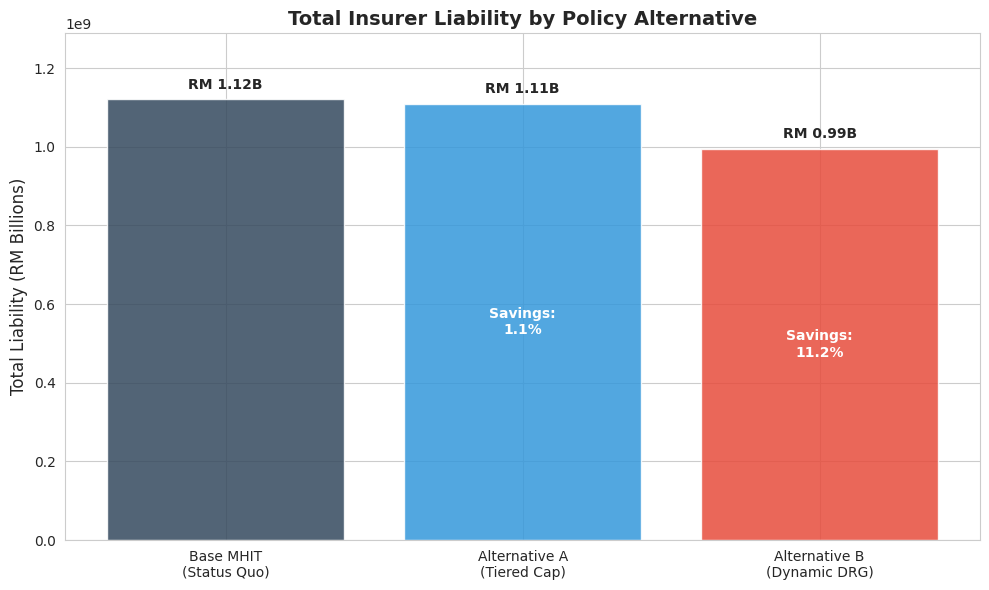

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for plotting
scenarios = ['Base MHIT\n(Status Quo)', 'Alternative A\n(Tiered Cap)', 'Alternative B\n(Dynamic DRG)']
liabilities = [insurer_total_status_quo, insurer_total_alt_a, insurer_total_alt_b]
savings = [0, savings_a, savings_b]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create bar plot
bars = plt.bar(scenarios, liabilities, color=['#34495e', '#3498db', '#e74c3c'], alpha=0.85)
plt.title('Total Insurer Liability by Policy Alternative', fontsize=14, fontweight='bold')
plt.ylabel('Total Liability (RM Billions)', fontsize=12)
plt.ylim(0, max(liabilities) * 1.15)

for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20000000, f'RM {yval/1e9:.2f}B',
             ha='center', va='bottom', fontweight='bold')

    if i > 0:
        pct_saving = (savings[i] / insurer_total_status_quo) * 100
        plt.text(bar.get_x() + bar.get_width()/2, yval / 2, f'Savings:\n{pct_saving:.1f}%',
                 ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### Policy Evaluation & Financial Impact
Our exploratory analysis revealed a critical flaw in the proposed Base MHIT Plan: **82% of claims breach the RM 3,000 co-payment cap.** To quantify this impact and test sustainable alternatives, we ran a portfolio-wide simulation using our Fair Market Value (FMV) benchmarks.

#### Macro-Level Impact: Portfolio Liability
*   **Status Quo (Base MHIT):** Under the current proposal (20% co-pay, RM 3,000 cap), the total insurer liability for this dataset is a massive **RM 1.12 Billion**.
*   **Alternative A (The Tiered Cap):** Raising the cap to RM 10,000 for inefficient (Tier 2) hospitals yielded **RM 12.07 Million (1.08%)** in savings. While helpful, it is a marginal improvement because it still shields patients from the true cost of extreme over-servicing.
*   **Alternative B (Dynamic DRG Cap - Recommended):** By removing the arbitrary cap, charging a flat 10% of the FMV, and passing 100% of any overcharge above the benchmark to the patient, insurer liability dropped to **RM 994.7 Million**. This generates **RM 125.67 Million (11.22%)** in savings, fundamentally stabilizing the risk pool.

#### Micro-Level Impact: How Alternative B Changes Consumer Behavior
The sample claims perfectly illustrate why Alternative B drives value-based healthcare:
*   **The Overcharging Penalty (Row 1):** A patient went to a hospital that charged **RM 28,087** for a procedure that should only cost **RM 24,313** (FMV). Under the Base MHIT plan, the patient pays RM 3,000. Under Alternative B, the patient pays **RM 6,206** (10% of FMV + 100% of the RM ~3.7k overage). The hospital's inefficiency is no longer subsidized by the insurer.
*   **The Efficiency Reward (Row 3):** A patient went to an efficient hospital that charged **RM 27,899** for a procedure with a benchmark FMV of **RM 30,269**. Under the Base MHIT plan, they hit the RM 3,000 cap. Under Alternative B, because there is zero overage, they only pay 10% of the FMV: **RM 3,027**.

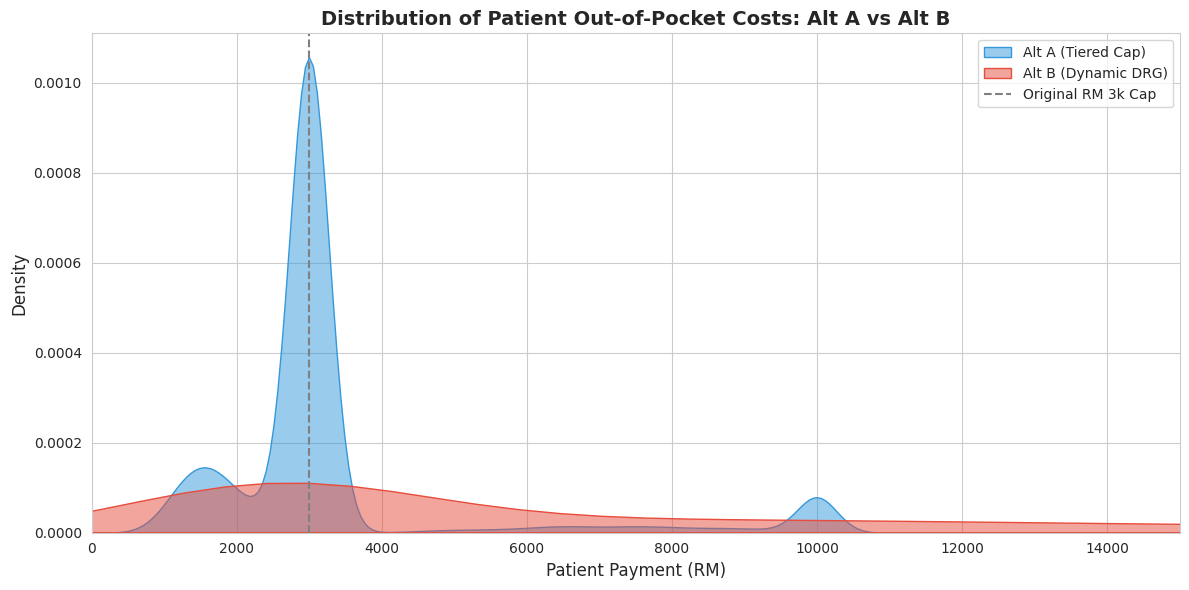

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Plotting the distributions of patient copays
sns.kdeplot(df['alt_a_patient_pays'], fill=True, color="#3498db", label="Alt A (Tiered Cap)", alpha=0.5)
sns.kdeplot(df['alt_b_patient_pays'], fill=True, color="#e74c3c", label="Alt B (Dynamic DRG)", alpha=0.5)

plt.title('Distribution of Patient Out-of-Pocket Costs: Alt A vs Alt B', fontsize=14, fontweight='bold')
plt.xlabel('Patient Payment (RM)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.axvline(3000, color='gray', linestyle='--', label='Original RM 3k Cap')

plt.legend()
plt.xlim(0, 15000)
plt.tight_layout()
plt.show()

The distribution plot reveals a fascinating contrast between the two policy designs. Under Alternative A (Tiered Cap), we see a massive spike right at the RM 3,000 mark, confirming that most patients are simply hitting their cap and losing any incentive to manage costs. In contrast, Alternative B (Dynamic DRG) spreads the costs much further out. You can see a significant portion of the population paying between RM 5,000 and RM 10,000—these are the patients who chose hospitals that charged above the Fair Market Value benchmark. This 'long tail' in Alt B is exactly what creates the savings for the insurer and the incentive for value-based care.



### Conclusion & Recommendation
We strongly recommend insurers adopt the **Dynamic DRG Cap (Alternative B)** to support the implementation of the Base MHIT plan. It provides immense financial predictability for insurers by hard-capping their liability at 90% of the Fair Market Value. Most importantly, it aligns patient incentives with system sustainability, rewarding patients who choose cost-efficient providers while heavily penalizing those who select hospitals that price gouge above the benchmark.